In [ ]:
# Veri işlemleri
import numpy as np
import pandas as pd

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# ML modelleri
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Performans ölçümü
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving diabetic_data.csv to diabetic_data (1).csv


In [ ]:
df = pd.read_csv("diabetic_data.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
#VERİYİ ANLA
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [ ]:
#"?" DEĞERLERİNİ TEMİZLE
df.replace("?", pd.NA, inplace=True)
print(df.shape)
print(df.isnull().sum().head())

(101766, 50)
encounter_id       0
patient_nbr        0
race            2273
gender             0
age                0
dtype: int64


In [ ]:
#GEREKSİZ KOLONLARI KALDIR
df.drop(["encounter_id", "patient_nbr"], axis=1, inplace=True)

print(df.shape)

(101766, 48)


In [ ]:
#TARGET (LABEL) DÜZENLE

#TARGET (y) OLUŞTUR
y = df["readmitted"].apply(lambda x: 1 if x == "<30" else 0)
print(y.shape)
print(y.value_counts())
#1 → hasta tekrar yatmış (risk)
#0 → diğerleri

(101766,)
readmitted
0    90409
1    11357
Name: count, dtype: int64


In [ ]:
#FEATURE (X) AYIR
X = df.drop("readmitted", axis=1)
print(X.shape)

(101766, 47)


In [ ]:
#MISSING VALUE DOLDUR

# sayısal kolonlar
num_cols = X.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

# kategorik kolonlar
cat_cols = X.select_dtypes(include=['object']).columns

for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

#Veri silmedik → doldurduk
print(X.shape)

(101766, 47)


In [ ]:
#CATEGORICAL VERİLERİ SAYIYA ÇEVİR
#X = pd.get_dummies(X)

In [ ]:
#ENCODING
X = pd.get_dummies(X)
print("After encoding:", X.shape)

After encoding: (101766, 2461)


In [ ]:
print("FINAL CHECK")
print("X:", X.shape)
print("y:", y.shape)

FINAL CHECK
X: (101766, 2461)
y: (101766,)


In [ ]:
#TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X.shape)
print(y.shape)

(101766, 2461)
(101766,)


In [ ]:
#SCALING
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Scaling tamamlandı")
#Verileri aynı ölçeğe getirdik

Scaling tamamlandı


In [ ]:
#LOGISTIC REGRESSION
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8854279257148472


In [ ]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.89      0.99      0.94     18069
           1       0.33      0.02      0.04      2285

    accuracy                           0.89     20354
   macro avg       0.61      0.51      0.49     20354
weighted avg       0.83      0.89      0.84     20354



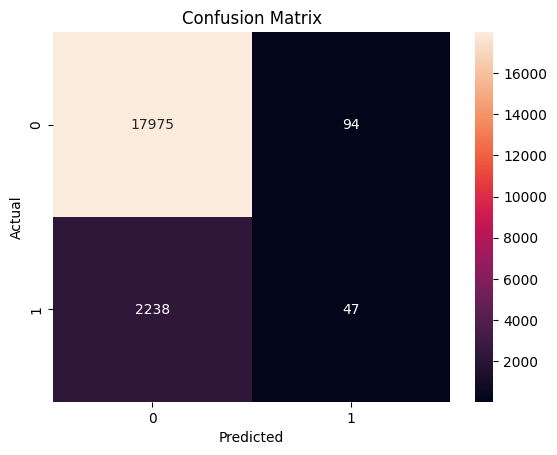

In [ ]:
#CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
#SVM
#svm = SVC()
#svm.fit(X_train, y_train)
#y_pred_svm = svm.predict(X_test)

#print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

In [ ]:
#SVM
from sklearn.svm import LinearSVC

svm = LinearSVC(max_iter=2000)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.8868035766925421


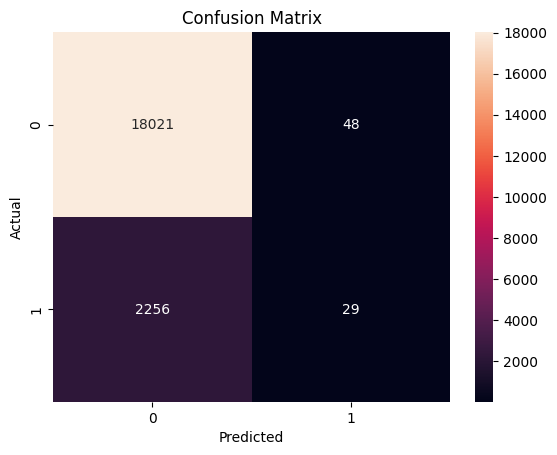

In [ ]:
#CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
#NEURAL NETWORK
nn = MLPClassifier(hidden_layer_sizes=(16,8), max_iter=500,
#nn = MLPClassifier(hidden_layer_sizes=(16,8), max_iter=30,
    early_stopping=True,
    n_iter_no_change=5,
    verbose=True)

nn.fit(X_train, y_train)

y_pred_nn = nn.predict(X_test)

print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_nn))

Iteration 1, loss = 0.39549819
Validation score: 0.888357
Iteration 2, loss = 0.32995884
Validation score: 0.888234
Iteration 3, loss = 0.32030306
Validation score: 0.887865
Iteration 4, loss = 0.31351907
Validation score: 0.888111
Iteration 5, loss = 0.30735500
Validation score: 0.887374
Iteration 6, loss = 0.30039697
Validation score: 0.886023
Iteration 7, loss = 0.29347175
Validation score: 0.885777
Validation score did not improve more than tol=0.000100 for 5 consecutive epochs. Stopping.
Neural Network Accuracy: 0.8875405325734499


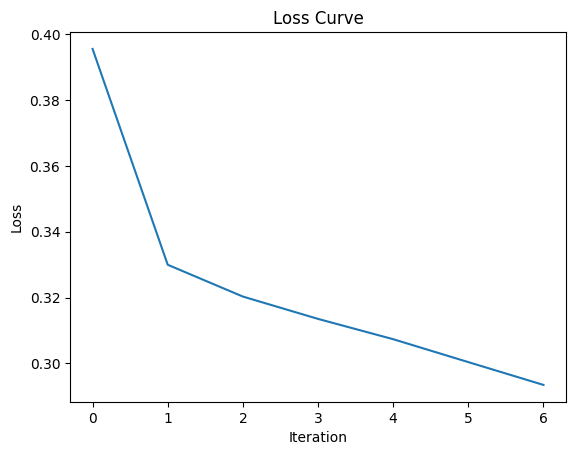

In [ ]:
plt.plot(nn.loss_curve_)
plt.title("Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

In [ ]:
##NEURAL NETWORK
'''nn = MLPClassifier(
    hidden_layer_sizes=(8,),   # küçük model
    max_iter=100,              # az iterasyon
    early_stopping=True        # erken durdur
)

nn.fit(X_train, y_train)

y_pred_nn = nn.predict(X_test)

print("NN Accuracy:", accuracy_score(y_test, y_pred_nn))'''

'nn = MLPClassifier(\n    hidden_layer_sizes=(8,),   # küçük model\n    max_iter=100,              # az iterasyon\n    early_stopping=True        # erken durdur\n)\n\nnn.fit(X_train, y_train)\n\ny_pred_nn = nn.predict(X_test)\n\nprint("NN Accuracy:", accuracy_score(y_test, y_pred_nn))'

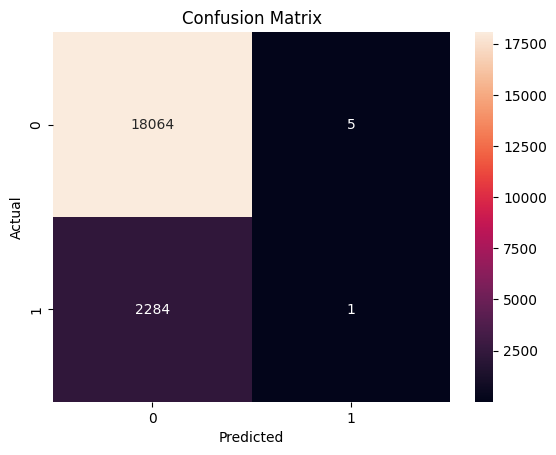

In [ ]:
#CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred_nn)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
'''#OPTIMIZER KARŞILAŞTIRMA
nn_sgd = MLPClassifier(solver='sgd', max_iter=500)
nn_adam = MLPClassifier(solver='adam', max_iter=500)

nn_sgd.fit(X_train, y_train)
nn_adam.fit(X_train, y_train)

acc_sgd = accuracy_score(y_test, nn_sgd.predict(X_test))
acc_adam = accuracy_score(y_test, nn_adam.predict(X_test))

print("SGD Accuracy:", acc_sgd)
print("Adam Accuracy:", acc_adam)'''

'#OPTIMIZER KARŞILAŞTIRMA\nnn_sgd = MLPClassifier(solver=\'sgd\', max_iter=500)\nnn_adam = MLPClassifier(solver=\'adam\', max_iter=500)\n\nnn_sgd.fit(X_train, y_train)\nnn_adam.fit(X_train, y_train)\n\nacc_sgd = accuracy_score(y_test, nn_sgd.predict(X_test))\nacc_adam = accuracy_score(y_test, nn_adam.predict(X_test))\n\nprint("SGD Accuracy:", acc_sgd)\nprint("Adam Accuracy:", acc_adam)'

In [ ]:
#OPTIMIZER KARŞILAŞTIRMA
nn_sgd = MLPClassifier(
    solver='sgd',
    #hidden_layer_sizes=(8,),
    max_iter=500,
    #max_iter=1000,
    early_stopping=True,
    n_iter_no_change=5,
    verbose=True
)

nn_adam = MLPClassifier(
    solver='adam',
    #hidden_layer_sizes=(8,),
    max_iter=500,
    #max_iter=1000,
    early_stopping=True,
    n_iter_no_change=5,
    verbose=True
)

nn_sgd.fit(X_train, y_train)
nn_adam.fit(X_train, y_train)

acc_sgd = accuracy_score(y_test, nn_sgd.predict(X_test))
acc_adam = accuracy_score(y_test, nn_adam.predict(X_test))

print("SGD Accuracy:", acc_sgd)
print("Adam Accuracy:", acc_adam)

Iteration 1, loss = 0.44652191
Validation score: 0.887988
Iteration 2, loss = 0.37405463
Validation score: 0.887620
Iteration 3, loss = 0.35233071
Validation score: 0.887497
Iteration 4, loss = 0.33954819
Validation score: 0.887128
Iteration 5, loss = 0.33135500
Validation score: 0.887497
Iteration 6, loss = 0.32572545
Validation score: 0.886514
Iteration 7, loss = 0.32166800
Validation score: 0.886514
Validation score did not improve more than tol=0.000100 for 5 consecutive epochs. Stopping.
Iteration 1, loss = 0.50486783
Validation score: 0.884426
Iteration 2, loss = 0.33352177
Validation score: 0.884058
Iteration 3, loss = 0.31161284
Validation score: 0.885286
Iteration 4, loss = 0.30085360
Validation score: 0.883690
Iteration 5, loss = 0.29346405
Validation score: 0.883690
Iteration 6, loss = 0.28355678
Validation score: 0.886023
Iteration 7, loss = 0.27040754
Validation score: 0.881847
Iteration 8, loss = 0.25676190
Validation score: 0.880865
Iteration 9, loss = 0.23911394
Validat

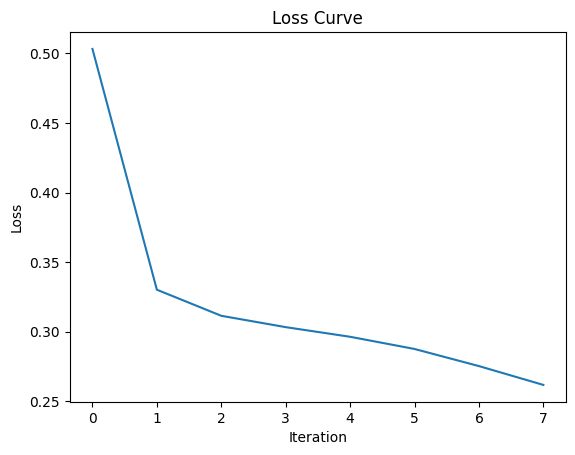

In [ ]:
plt.plot(nn_adam.loss_curve_)
plt.title("Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

In [ ]:
#SONUÇ TABLOSU
results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Neural Net (SGD)", "Neural Net (Adam)"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, nn_sgd.predict(X_test)), #acc_sgd
        accuracy_score(y_test, nn_adam.predict(X_test)) #acc_adam
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.885428
1,SVM,0.886804
2,Neural Net (SGD),0.887491
3,Neural Net (Adam),0.885379


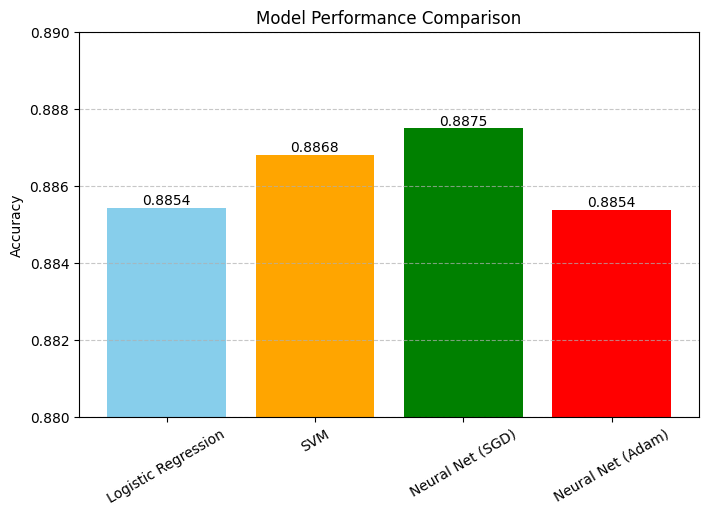

In [ ]:
colors = ["skyblue", "orange", "green", "red"]

plt.figure(figsize=(8,5))

bars = plt.bar(results["Model"], results["Accuracy"], color=["skyblue","orange","green","red"])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4),
             ha='center', va='bottom')

plt.title("Model Performance Comparison")
plt.ylabel("Accuracy")

plt.ylim(0.88, 0.89)

plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()